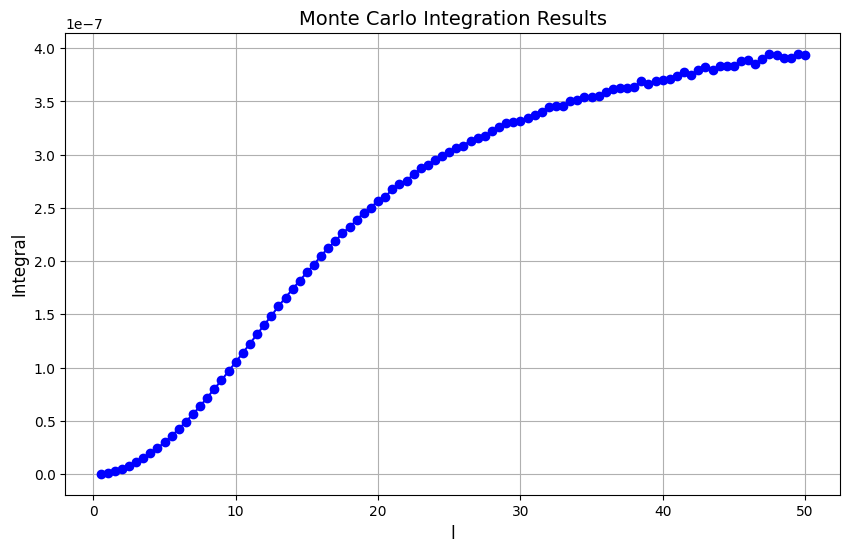

In [1]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt

#Constant
k = 4 * 22 * 4.301 * 0.01992e9 / (7 * const.c**2)     # G = 4.301e-6

# Function for r
def r_fn(l, x, x0):
    return l * np.sqrt(x0**2 - 2 * x * x0 * np.cos(np.radians(280)) * np.cos(np.radians(-33)) + x**2)

# Function for the integrand
def integrand(x, l, x0, rh, n):
    r = r_fn(l, x, x0)
    return k * (l**2) * x * (1 - x) * np.exp(- (r / rh)**(1/n))

# Monte Carlo integration function
def monte_carlo_integrate(func, l, x0, n, rh, num_samples=100000):
    x_samples = np.random.uniform(0, 1, num_samples)  # Samples of x in the range [0, 1]
    
    # Calculate integral using Monte Carlo method
    integral_values = np.zeros(num_samples)
    for i in range(num_samples):
        x = x_samples[i]
        integral_values[i] = func(x, l, x0, rh, n)
    
    # Mean of the integrand times the width of the integration range (1 - 0)
    return np.mean(integral_values)

# Parameters
rh = 11.41
n = 0.43

# Loop over l values and perform the integration
l_values = np.arange(0.5, 50.5, 0.5)  # l from 0.5 to 50 with a step of 0.5
results = []

# Perform Monte Carlo integration for each value of l
for l in l_values:
    x0 = 8.5 / l  # x0 = 8.5 / l given
    integral = monte_carlo_integrate(integrand, l, x0, n, rh)
    results.append((l, integral))

# Unzip results into two lists
l_vals, integrals = zip(*results)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(l_vals, integrals, marker='o', linestyle='-', color='b')
plt.title('Monte Carlo Integration Results', fontsize=14)
plt.xlabel('l', fontsize=12)
plt.ylabel('Integral', fontsize=12)
plt.grid(True)
plt.show()
